# Parte 1
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

In [1]:
import numpy as np
import cv2

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:

def white_patch_percentile(image, percentile):
    pixels = image.reshape(-1, image.shape[-1])

    illum = np.percentile(
        pixels,
        percentile,
        axis=0
    )

    balanced = image / illum

    scaled = balanced * 255.0
    scaled /= balanced.max()    # normalize to max value in based on percentile
    scaled = np.clip(scaled, 0, 255)

    return scaled.astype(np.uint8)

def white_patch_max(image):
    pixels = image.reshape(-1, image.shape[-1])

    illum = pixels.max(axis=0)

    balanced = image / illum

    scaled = balanced * 255.0
    scaled = np.clip(scaled, 0, 255)

    return scaled.astype(np.uint8)


def create_image(image, image_path, name):
    aux = image_path.split(".")
    image_name = "".join(aux[0]) + f"_{name}." + aux[1]
    
    cv2.imwrite(image_name, image)

def white_patch(image_path, percentile=100, save_image=False):    
    img = cv2.imread(image_path)

    patched = white_patch_max(img)

    if save_image:
        create_image(patched, image_path, "white_patched")
    
    images = 2
    if percentile < 100:
        images = 3

        patched_percentile = white_patch_percentile(img, percentile)
        if save_image:
            create_image(patched_percentile, image_path, "white_patched_percentile")


    height, width = img.shape[:2]
    if width > height:  # Horizontal        
        fig, axes = plt.subplots(images, 1)
    else:   # Vertical                
        fig, axes = plt.subplots(1, images)

    axes[0].set_title("Original")
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt_wb = cv2.cvtColor(patched, cv2.COLOR_BGR2RGB)
    axes[1].set_title("White patched")
    axes[1].imshow(plt_wb)
    
    if images == 3:
        axes[2].set_title(f"White patched with percentile {percentile}")
        axes[2].imshow(cv2.cvtColor(patched_percentile, cv2.COLOR_BGR2RGB))

    plt.tight_layout()
    plt.show()


white patching - test_blue.png


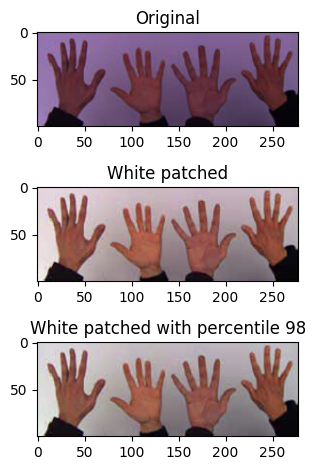

white patching - test_green.png


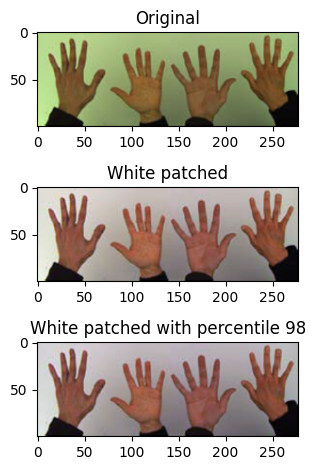

white patching - test_red.png


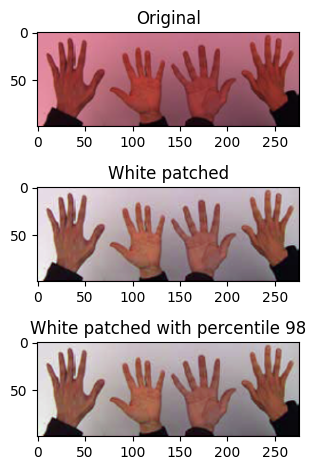

white patching - wp_blue.jpg


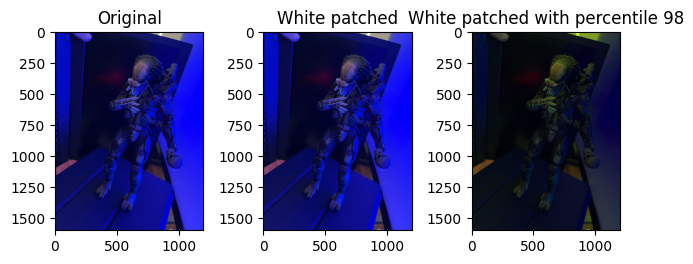

white patching - wp_green.png


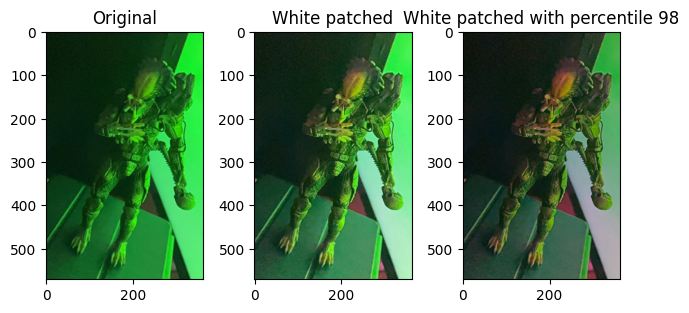

white patching - wp_green2.jpg


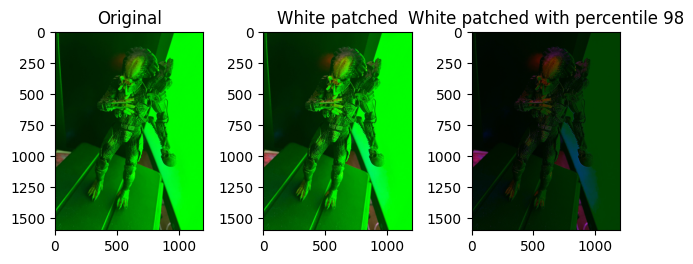

white patching - wp_red.png


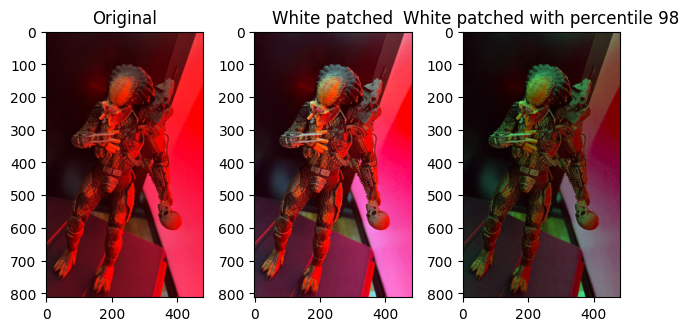

white patching - wp_red2.jpg


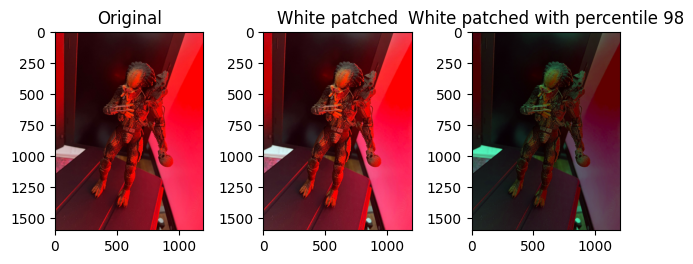

In [4]:
from pathlib import Path

path = Path('white_patch')
files = sorted(path.iterdir())
for file in files:
    if file.is_file():
        print(f"white patching - {file.name}")
        white_patch(f"white_patch/{file.name}", percentile=98, save_image=True)

En las imagenes de las manos se aprecia que el algoritmo de white-patch logra recuperar bastante el color original de la imagen, lo que implica que dentro de la imagen original se logra encontrar un punto lo suficientemente brillante para asignarlos como la referencia de "blanco". Aplicando la correccion con el percentil las imagenes no cambian mucho, lo que podria implicar que el maximo valor obtenido esta saturado o cerca de hacerlo.

En las imagenes de los aliens se observa que el algoritmo ya no tuvo una buena performance. Esto puede deberse a que las imagenes tienen un color sumamente dominante, haciendo que los otros canales queden sobrecompensados. 
Para los casos de `wp_blue.jpg`, `wp_green2.jpg` y `wp_red2.jpg`, practicamente no se ve diferencia entre la imagen original y la white patcheada (sin percentil). Eso debe ocurrir por la ausencia practicamente total de los otros dos canales en la imagen. Al aplicar el algoritmo con percentil 98, se ve claramente una modificacion, pero la imagen pierde brillo. Esto se debe a que los canales de los colores no dominantes se aplifican mucho.
En `wp_green.png` y `wp_red.png` se ve una pequeña correccion de color, lo que indica que, si bien las imagenes las vemos con un color dominante, no hay tanta perdida de los otros canales.

# Parte 2
1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grises y visualizarlas.
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

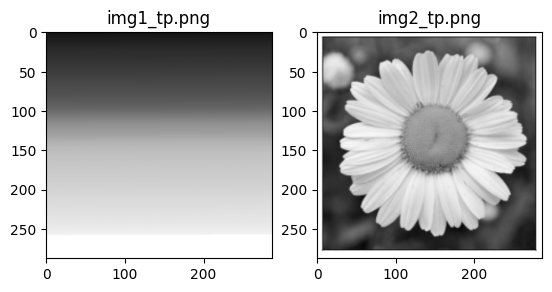

In [6]:

fig, axes = plt.subplots(1, 2)

img1 = cv2.imread("img1_tp.png", cv2.IMREAD_GRAYSCALE)
axes[0].set_title("img1_tp.png")
axes[0].imshow(img1, cmap='gray')

img2 = cv2.imread("img2_tp.png", cv2.IMREAD_GRAYSCALE)
axes[1].set_title("img2_tp.png")
axes[1].imshow(img2, cmap='gray')


plt.show()

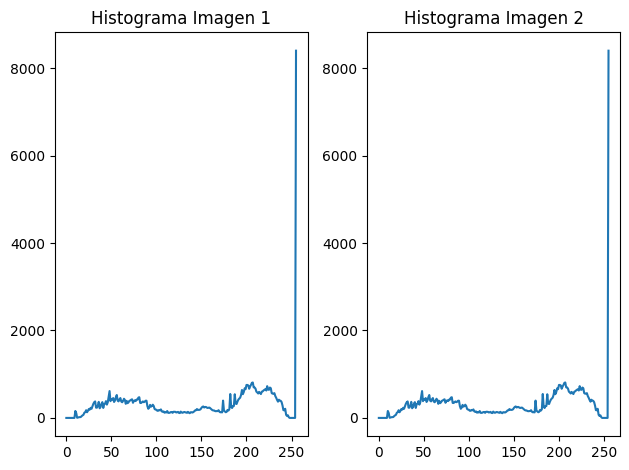

In [7]:
bins = 256

fig, (ax1, ax2) = plt.subplots(1, 2)

hist, bins = np.histogram(img1.ravel(), bins=bins, range=[0, 256])
ax1.set_title("Histograma Imagen 1")
ax1.plot(hist)

hist, bins = np.histogram(img2.ravel(), bins=bins, range=[0, 256])
ax2.set_title("Histograma Imagen 2")
ax2.plot(hist)

plt.tight_layout()
plt.show()


Elijo 256 bins para representar la distinta intensidad del gris en cada pixel (de 0 a 255).
En los histogramas observamos que ambas imagenes tienen la misma distribucion de intensidad de pixeles, solo que estan ordenados de forma distinta, generando distintas imagenes.
Se ve que en 255 hay un pico de mas de 8000 pixeles en esa intensidad. Eso implica que las imagenes estan en varias partes saturados (en color blanco). Esto hace bastante complejo de leer en mayor detalle el histograma.

Para el caso de identificacion de imagenes, los histogramas no resultan utiles como features. Podrian servir para clasificar si la imagen esta saturada, si tiene muchos tonos oscuros o claros, o si quisieramos identificar si fue modificada o no.